# 2장 실습 — 수집 경로별 데이터 품질

1장이 계약을 세웠고 대본 전문가가 과제를 푼다는 것을 확인했다. 이 노트북은 **그 전문가로 무엇을 모을 것인가**를 정한다.

시연을 만드는 길이 여럿이다. 다섯 경로를 같은 자에 올린다.

- **대본 전문가** — 손으로 쓴 제어기가 매번 같은 방식으로 움직인다
- **잡음 주입** — 전문가 명령에 잡음을 섞어 실행하고, 라벨은 깨끗한 명령을 남긴다
- **원격조작 대용** — 사람의 손떨림과 망설임을 흉내 내고, 사람이 낸 명령이 라벨이 된다
- **자율 주행 + 전문가 라벨** — 1장의 정책이 굴리고 전문가가 그 상태에 라벨을 단다
- **혼합** — 대본 전문가와 자율 주행 데이터를 반씩 섞는다

예산은 **라벨한 스텝 수**로 맞춘다. 벽시계 시간이 아닌 이유는 뒤에 적는다.

이 노트북이 남기는 것은 `data/demos_v1.npz`(고른 경로의 데이터)와 `data/collect.json`(수집 설정)이다. 3장이 이 둘을 읽는다.

실행 시간은 CPU에서 10분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

## 다섯 수집 경로

경로를 가르는 것은 두 가지다. **무엇이 로봇을 움직이는가**(실행 명령)와 **무엇이 기록되는가**(라벨)다.

| 경로 | 실행 명령 | 기록 라벨 |
|---|---|---|
| 대본 전문가 | 전문가 | 전문가 |
| 잡음 주입 | 전문가 + 잡음 | 전문가 |
| 원격조작 대용 | 전문가 + 잡음 + 정지 | 실행 명령 그대로 |
| 자율 주행 + 라벨 | 1장 정책 | 전문가 |
| 혼합 | 위 첫째와 넷째 | 전문가 |


In [7]:
SIG = .22                        # 잡음 표준편차 (정규화 단위)


def teleop(env, rng, jitter=SIG, pause=.07):
    """원격조작 대용 — 손떨림과 망설임"""
    a = servo(env) + rng.normal(0, jitter, (env.n, 2))
    a[rng.random(env.n) < pause] = 0.
    return np.clip(a, -1, 1).astype(np.float32)


P0 = "policy/v0.pt"
if os.path.exists(P0):
    V0 = torch.load(P0, weights_only=False)
    print(f"1장이 남긴 {P0} 를 불러왔다")
else:
    print(f"{P0} 가 없다 — 1장과 같은 설정으로 다시 학습한다")
    t0 = time.time()
    V0 = train_rl(seed=0)
    os.makedirs("policy", exist_ok=True)
    torch.save(V0, P0)
    print(f"학습 끝  ({time.time() - t0:.0f}s)")


def collect(path, steps=40_000, n=64, seed=5):
    """관측, 기록 라벨, 전문가 명령을 함께 남긴다"""
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    env = Cell(n, seed)
    O, L, S = [], [], []
    ep = 0
    while len(O) * n < steps:
        o = env.obs()
        ex = servo(env)
        lab = ex
        if path == "대본 전문가":
            act = ex
        elif path == "잡음 주입":
            act = np.clip(ex + rng.normal(0, SIG, ex.shape), -1, 1)
        elif path == "원격조작 대용":
            act = teleop(env, rng)
            lab = act                    # 사람이 낸 것이 기록된다
        else:                            # 자율 주행 + 라벨
            with torch.no_grad():
                act = V0.dist(torch.from_numpy(o)).sample().numpy()
        O.append(o)
        L.append(lab)
        S.append(ex)
        _, _, sc = env.step(act.astype(np.float32))
        ep += len(sc)
    cut = lambda z: np.concatenate(z)[:steps].astype(np.float32)
    return cut(O), cut(L), cut(S), ep


BASE = ["대본 전문가", "잡음 주입", "원격조작 대용",
        "자율 주행 + 라벨"]
t0 = time.time()
DATA, EPS = {}, {}
for p in BASE:
    X, Y, S, EPS[p] = collect(p)
    DATA[p] = (X, Y, S)

# 혼합 — 반씩 잘라 붙인 뒤 섞는다. 섞지 않으면
# 앞에서 자른 부분집합이 한쪽 경로만 담게 된다
h = 20_000
E, U = DATA["대본 전문가"], DATA["자율 주행 + 라벨"]
mix = [np.concatenate([E[i][:h], U[i][:h]]) for i in range(3)]
perm = np.random.default_rng(0).permutation(2 * h)
DATA["혼합"] = tuple(z[perm] for z in mix)
EPS["혼합"] = (EPS["대본 전문가"] + EPS["자율 주행 + 라벨"]) // 2

PATHS = BASE + ["혼합"]
print(f"수집 끝  ({time.time() - t0:.0f}s)\n")
print(pad("수집 경로", 18) + pad("스텝", 9, True)
      + pad("판", 7, True) + pad("판당 스텝", 11, True))
for p in PATHS:
    n = len(DATA[p][0])
    print(pad(p, 18) + pad(f"{n:,}", 9, True) + pad(EPS[p], 7, True)
          + pad(f"{n / EPS[p]:.0f}", 11, True))

1장이 남긴 policy/v0.pt 를 불러왔다


수집 끝  (28s)

수집 경로              스텝     판  판당 스텝
대본 전문가          40,000    840         48
잡음 주입            40,000    825         48
원격조작 대용        40,000    769         52
자율 주행 + 라벨     40,000   1985         20
혼합                 40,000   1412         28


## 데이터를 재는 세 지표

학습 전에 데이터만 보고 성적을 예고할 수 있는가. 세 지표를 잰다.

- **점유 칸** — 밀대와 부품의 상대 위치 평면을 24×24 격자로 나눠 데이터가 밟은 칸 수를 센다. 격자의 범위는 다섯 집합을 합친 분포의 1–99 백분위로 잡는다
- **기준 상태 거리** — 전문가가 배포 조건에서 실제로 지나가는 상태 1만 9천여 개를 모아 두고, 각각에서 가장 가까운 학습 데이터까지의 거리를 평균한다. 「필요한 곳을 덮었는가」를 잰다
- **라벨 잡음** — 기록 라벨과 전문가 명령의 차이(RMS)다

In [8]:
def occupancy(Z, lo, hi, bins=24):
    q = ((Z - lo) / (hi - lo) * bins).astype(int)
    q = np.clip(q, 0, bins - 1)
    return len(set(map(tuple, q.tolist())))


def ref_states(n=64, T=300, seed=77):
    """전문가가 배포 조건에서 지나가는 상태"""
    env = Pert(n, seed, **COND["배포"])
    R = []
    for _ in range(T):
        R.append(env.obs())
        env.step(servo(env))
    return np.concatenate(R)


def nn_dist(X, R, chunk=512):
    """R 의 각 점에서 X 의 가장 가까운 점까지 거리 (8차원)"""
    Xt = torch.from_numpy(X[:, :8])
    out = []
    for i in range(0, len(R), chunk):
        Rt = torch.from_numpy(R[i:i + chunk, :8])
        out.append(torch.cdist(Rt, Xt).min(1).values)
    return torch.cat(out).numpy()


REF = ref_states()
Z = np.concatenate([DATA[p][0][:, 4:6] for p in PATHS])
LO, HI = np.percentile(Z, 1, 0), np.percentile(Z, 99, 0)
MET = {}
for p in PATHS:
    X, Y, S = DATA[p]
    MET[p] = (occupancy(X[:, 4:6], LO, HI), nn_dist(X, REF).mean(),
              np.sqrt(((Y - S) ** 2).mean()))

print(f"기준 상태 {len(REF):,}개\n")
print(pad("수집 경로", 18) + pad("점유 칸", 9, True)
      + pad("기준 상태 거리", 16, True)
      + pad("라벨 잡음", 11, True))
for p in PATHS:
    o, d, e = MET[p]
    print(pad(p, 18) + pad(o, 9, True) + pad(f"{d:.3f}", 16, True)
          + pad(f"{e:.3f}", 11, True))

기준 상태 19,200개

수집 경로           점유 칸  기준 상태 거리  라벨 잡음
대본 전문가             187           0.297      0.000
잡음 주입               498           0.226      0.000
원격조작 대용           489           0.224      0.238
자율 주행 + 라벨        297           1.036      0.000
혼합                    320           0.303      0.000


## 같은 예산, 다섯 정책

다섯 집합으로 각각 행동 복제를 학습한다. 학습 설정은 같고 데이터만 다르다. 1장의 계약대로 시드 셋, 두 조건, 조건마다 450판을 잰다.

In [9]:
SHORT = dict(zip(PATHS,
                 ("expert", "dart", "teleop", "auto", "mix")))
SEEDS = (0, 1, 2)
t0 = time.time()
FIT, LOG, SC = {}, [], {}
for p in PATHS:
    X, Y, _ = DATA[p]
    FIT[p] = [bc(X, Y, seed=s) for s in SEEDS]
    for c in COND:
        SC[(p, c)] = []
        for s, m in zip(SEEDS, FIT[p]):
            rows = rollout(mean_act(m), c, tag=s,
                           ver=f"bc-{SHORT[p]}")
            LOG += rows
            SC[(p, c)].append(rate(rows))
    print(f"{p} 끝  ({time.time() - t0:.0f}s)", flush=True)

대본 전문가 끝  (70s)


잡음 주입 끝  (139s)


원격조작 대용 끝  (208s)


자율 주행 + 라벨 끝  (276s)


혼합 끝  (346s)


In [10]:
def row(p):
    out = pad(p, 18)
    for c in COND:
        v = SC[(p, c)]
        out += (pad(f"{np.mean(v):.3f}", 8, True)
                + pad(f"[{min(v):.2f}, {max(v):.2f}]", 15, True))
    return out


print(pad("수집 경로", 18) + pad("명목", 8, True)
      + pad("범위", 15, True) + pad("배포", 8, True)
      + pad("범위", 15, True))
for p in PATHS:
    print(row(p))

수집 경로             명목           범위    배포           범위
대본 전문가          0.966   [0.96, 0.97]   0.780   [0.74, 0.81]
잡음 주입            1.000   [1.00, 1.00]   0.903   [0.87, 0.95]
원격조작 대용        1.000   [1.00, 1.00]   0.837   [0.78, 0.91]
자율 주행 + 라벨     0.001   [0.00, 0.00]   0.021   [0.02, 0.03]
혼합                 0.906   [0.73, 1.00]   0.893   [0.86, 0.92]


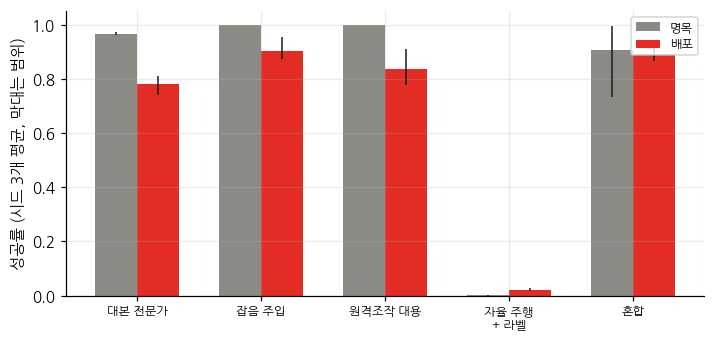

In [11]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
x = np.arange(len(PATHS))
w = .34
for i, (c, col) in enumerate((("명목", GREY), ("배포", RED))):
    v = np.array([np.mean(SC[(p, c)]) for p in PATHS])
    lo = v - np.array([min(SC[(p, c)]) for p in PATHS])
    hi = np.array([max(SC[(p, c)]) for p in PATHS]) - v
    ax.bar(x + (i - .5) * w, v, w, yerr=[lo, hi], color=col,
           label=c, error_kw=dict(lw=1, ecolor=INK))
ax.set_xticks(x)
ax.set_xticklabels([p.replace(" + ", "\n+ ") for p in PATHS],
                   fontsize=8)
ax.set_ylabel("성공률 (시드 3개 평균, 막대는 범위)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 지표와 성적을 나란히 놓는다

데이터 지표가 배포 성공률을 얼마나 예고했는지 한 표로 본다.

In [12]:
print(pad("수집 경로", 18) + pad("점유 칸", 9, True)
      + pad("기준 거리", 11, True) + pad("라벨 잡음", 11, True)
      + pad("배포 성공", 11, True))
for p in PATHS:
    o, d, e = MET[p]
    print(pad(p, 18) + pad(o, 9, True) + pad(f"{d:.3f}", 11, True)
          + pad(f"{e:.3f}", 11, True)
          + pad(f"{np.mean(SC[(p, '배포')]):.3f}", 11, True))

수집 경로           점유 칸  기준 거리  라벨 잡음  배포 성공
대본 전문가             187      0.297      0.000      0.780
잡음 주입               498      0.226      0.000      0.903
원격조작 대용           489      0.224      0.238      0.837
자율 주행 + 라벨        297      1.036      0.000      0.021
혼합                    320      0.303      0.000      0.893


## 예산을 훑는다

한 예산만 보고 정하지 않는다. 라벨 수를 5천과 2만으로 줄여 같은 비교를 다시 한다. 시드는 셋이고 배포 조건만 200판씩 잰다. 4만 점은 앞 표의 값을 그대로 쓴다. 자율 주행 단독 경로는 4만에서도 성공하지 못했으므로 뺀다.

In [13]:
BUD = (5_000, 20_000)
CUR = [p for p in PATHS if p != "자율 주행 + 라벨"]
CURVE = {p: [] for p in CUR}
t0 = time.time()
for b in BUD:
    for p in CUR:
        X, Y, _ = DATA[p]
        rs = [rate(rollout(mean_act(bc(X[:b], Y[:b], seed=s)),
                           "배포", n=100, reps=2)) for s in SEEDS]
        CURVE[p].append(rs)
    print(f"  {b:,} 스텝 끝  ({time.time() - t0:.0f}s)", flush=True)
for p in CUR:
    CURVE[p].append(SC[(p, "배포")])

BUDS = BUD + (40_000,)
print()
print(pad("라벨 수", 9) + "".join(pad(p, 16, True) for p in CUR))
for i, b in enumerate(BUDS):
    cells = [f"{np.mean(v[i]):.3f} ±{np.ptp(v[i]) / 2:.2f}"
             for v in (CURVE[p] for p in CUR)]
    print(pad(f"{b:,}", 9)
          + "".join(pad(c, 16, True) for c in cells))

  5,000 스텝 끝  (99s)


  20,000 스텝 끝  (198s)



라벨 수       대본 전문가       잡음 주입   원격조작 대용            혼합
5,000         0.783 ±0.07     0.732 ±0.10     0.767 ±0.04     0.898 ±0.03
20,000        0.831 ±0.04     0.939 ±0.01     0.864 ±0.07     0.918 ±0.02
40,000        0.780 ±0.03     0.903 ±0.04     0.837 ±0.07     0.893 ±0.03


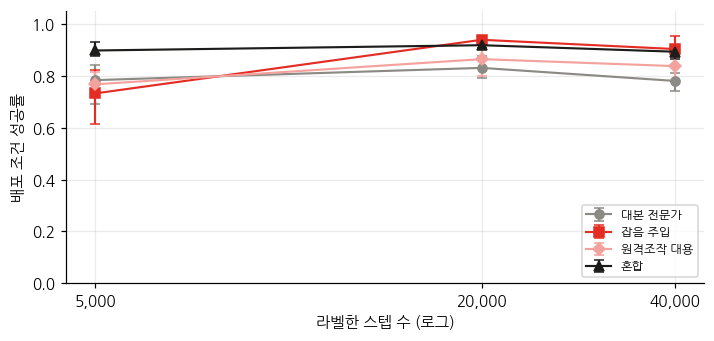

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
for p, col, mk in zip(CUR, (GREY, RED, PINK, INK), "osD^"):
    m = [np.mean(v) for v in CURVE[p]]
    lo = [m[i] - min(v) for i, v in enumerate(CURVE[p])]
    hi = [max(v) - m[i] for i, v in enumerate(CURVE[p])]
    ax.errorbar(BUDS, m, yerr=[lo, hi], color=col, marker=mk,
                capsize=3, lw=1.4, label=p)
ax.set_xscale("log")
ax.set_xticks(BUDS)
ax.set_xticklabels([f"{b:,}" for b in BUDS])
ax.minorticks_off()
ax.set_xlabel("라벨한 스텝 수 (로그)")
ax.set_ylabel("배포 조건 성공률")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 벽시계 시간은 왜 안 쓰는가

이 노트북은 예산을 **라벨한 스텝 수**로 맞췄다. 다섯 경로의 시뮬레이션 비용이 거의 같기 때문이다. 실기에서는 그렇지 않다.

UMI 는 실측을 공개한 몇 안 되는 사례다. 3D 프린팅 집게 **73 달러**와 GoPro 일습 **298 달러**로 만든 장비가, 컵 정렬 과제에서 **원격조작보다 3배 빠르고 사람 손의 48% 속도**로 시연을 만들었다. 던지기 과제에서는 사람 손의 64% 속도였고, 같은 과제에서 **원격조작은 15분 동안 성공한 시연을 하나도 만들지 못했다.**

그러니 실기의 예산표는 이 노트북의 표와 다르게 생겼다. **이 노트북이 재는 것은 「같은 라벨 수에서 어느 데이터가 나은가」이고, 「같은 시간에 어느 경로가 라벨을 더 만드는가」는 자기 현장에서 재야 한다.**

## 수집 설정을 고정한다

고르는 규칙을 코드로 적는다. **배포 평균이 가장 높은 경로와 시드 범위가 겹치는 경로 가운데, 의존성이 가장 적은 것을 고른다.** 의존성은 대본 전문가·잡음 주입이 0, 원격조작이 1(사람), 자율 주행과 혼합이 2(학습된 정책)다.

In [15]:
DEP = {"대본 전문가": 0, "잡음 주입": 0, "원격조작 대용": 1,
       "자율 주행 + 라벨": 2, "혼합": 2}
mean_d = {p: np.mean(SC[(p, "배포")]) for p in PATHS}
top = max(PATHS, key=mean_d.get)
floor = min(SC[(top, "배포")])
tie = [p for p in PATHS if max(SC[(p, "배포")]) >= floor]
pick = min(tie, key=lambda p: (DEP[p], -mean_d[p]))
print(f"배포 평균 최고 : {top}  ({mean_d[top]:.3f})")
print(f"범위가 겹치는 경로: {', '.join(tie)}")
print(f"고른 경로      : {pick}")

os.makedirs("data", exist_ok=True)
X, Y, _ = DATA[pick]
np.savez_compressed("data/demos_v1.npz", X=X, Y=Y)
CFG = {"path": pick, "sigma": SIG if pick == "잡음 주입" else 0.,
       "label": "servo", "steps": int(len(X)),
       "episodes": int(EPS[pick]),
       "deploy_mean": round(float(mean_d[pick]), 3),
       "deploy_range": [round(float(v), 3)
                        for v in (min(SC[(pick, "배포")]),
                                  max(SC[(pick, "배포")]))]}
with open("data/collect.json", "w") as f:
    json.dump(CFG, f, ensure_ascii=False, indent=1)
save_log("report/ch02_log.csv", LOG)
print()
print("남긴 산출물")
print(f"  data/demos_v1.npz     {len(X):,} 스텝")
print("  data/collect.json")
print("   ", json.dumps(CFG, ensure_ascii=False))
print(f"  report/ch02_log.csv   판별 로그 {len(LOG):,}줄")

배포 평균 최고 : 잡음 주입  (0.903)
범위가 겹치는 경로: 잡음 주입, 원격조작 대용, 혼합
고른 경로      : 잡음 주입



남긴 산출물
  data/demos_v1.npz     40,000 스텝
  data/collect.json
    {"path": "잡음 주입", "sigma": 0.22, "label": "servo", "steps": 40000, "episodes": 825, "deploy_mean": 0.903, "deploy_range": [0.874, 0.953]}
  report/ch02_log.csv   판별 로그 21,421줄


## 정리

**수집 경로는 두 축으로 갈린다 — 무엇이 로봇을 움직이는가, 무엇이 기록되는가.** 잡음은 실행에 넣고 라벨에서 뺀다. 같은 크기의 잡음이 실행에 들어가면 배포 성공률을 0.780에서 0.903으로 올렸고, 라벨에까지 들어가면 0.837에 그쳤다.

**자율 주행 데이터는 혼자서는 쓸모가 없다.** 전문가 라벨을 달아도 명목 0.001이다. 전문가 데이터와 섞을 때 값을 하고, 적은 예산에서 특히 그렇다.

**커버리지 지표는 방향만 맞힌다.** 전문가의 궤적을 기준으로 재는 지표는 라벨 품질도, 학습자가 실수해서 가는 곳도 보지 못한다.

**순위는 예산에 따라 뒤집히고, 2만 스텝 이후는 평평하다.** 그래서 경로 하나를 고르는 규칙을 코드로 적었다 — 배포 평균 최고와 범위가 겹치는 경로 가운데 의존성이 가장 적은 것.

이 장이 고른 것은 **잡음 주입(표준편차 0.22)** 이고, `data/demos_v1.npz` 와 `data/collect.json` 이 3장으로 넘어간다. 3장은 이 경로로 **얼마나** 모을지를 정한다.